### setup

In [ ]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def save_show(fig, name):
    path = OUT_DIR / f'{name}.png'
    fig.savefig(path)
    plt.close(fig)
    display(Image(path))

### Sort-of-CLEVR example

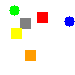

In [2]:
soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
plt.imsave(OUT_DIR / 'soc_example.png', soc['images'][scene][..., ::-1])   # stored BGR (cv2)
display(Image(OUT_DIR / 'soc_example.png'))

### SQOOP examples

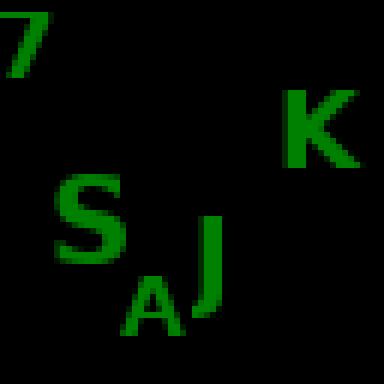

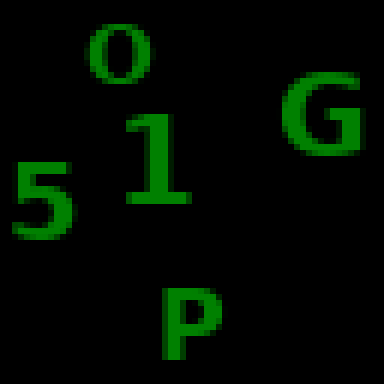

In [3]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)

for i in range(2):
    plt.imsave(OUT_DIR / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(OUT_DIR / f'sqoop_example_{i}.png'))

### results — placeholder data

In [4]:
# Every entry is an array of per-seed values. Replace with real results.
rng = np.random.default_rng(0)
N_SEEDS = 5
FAMILIES = ['Overall', 'Non-relational', 'Binary', 'Ternary']


def fake(xs, curve, sd=1.5):
    """{x: (N_SEEDS,) array} for each family, from a smooth placeholder curve."""
    return {fam: {x: np.clip(curve(x) + off + sd * rng.standard_normal(N_SEEDS), 0, None)
                  for x in xs}
            for fam, off in zip(FAMILIES, [0, 10, -2, -10])}


T_CANON, M_CANON, D_CANON = 6, 4, 6
T_TEST = [0, 1, 2, 4, 6, 8, 12, 16]
T_TRAIN = [0, 1, 2, 4, 6, 8, 12]
M_VALUES = [1, 2, 4, 6, 8, 12]
D_VALUES = [2, 3, 4, 6, 8, 12]

RES = {
    't_test': fake(T_TEST, lambda t: 40 * np.exp(-((t - T_CANON) / 5) ** 2)),
    't_train': fake(T_TRAIN, lambda t: 42 * (1 - np.exp(-t / 3))),
    'n_modules': fake(M_VALUES, lambda m: 42 - 3 * abs(np.log2(m / M_CANON))),
    'phase_dim': fake(D_VALUES, lambda d: 44 * (1 - np.exp(-d / 2.5))),
}

# joint (train, test) grid: (len(T_TRAIN), len(T_TEST), N_SEEDS) overall accuracy
T_GRID = np.array([[42 * (1 - np.exp(-tr / 3)) * np.exp(-((te - tr) / (2 + 0.6 * tr)) ** 2)
                    for te in T_TEST[1:]] for tr in T_TRAIN[1:]])
T_GRID = T_GRID[..., None] + 1.5 * rng.standard_normal((*T_GRID.shape, N_SEEDS))

# SQOOP: {model: {split: {variety: (N_SEEDS,)}}}
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
SQOOP_MODELS = ['Q-Only', 'CNN+MLP', 'Conv+LSTM', 'RelNet', 'FiLM', 'Transformer', 'Workspace', 'SyncNet']
SQOOP = {}
for k, name in enumerate(SQOOP_MODELS):
    top = 0.5 if name == 'Q-Only' else 0.7 + 0.035 * k
    SQOOP[name] = {
        'validation': {v: (0.5 if name == 'Q-Only' else 0.98) + 0.005 * rng.standard_normal(N_SEEDS) for v in PAIR_VARIETY},
        'held-out': {v: 0.5 + (top - 0.5) * (1 - np.exp(-0.25 * v)) + 0.015 * rng.standard_normal(N_SEEDS) for v in PAIR_VARIETY},
    }

### results — Sort-of-CLEVR ablation plots

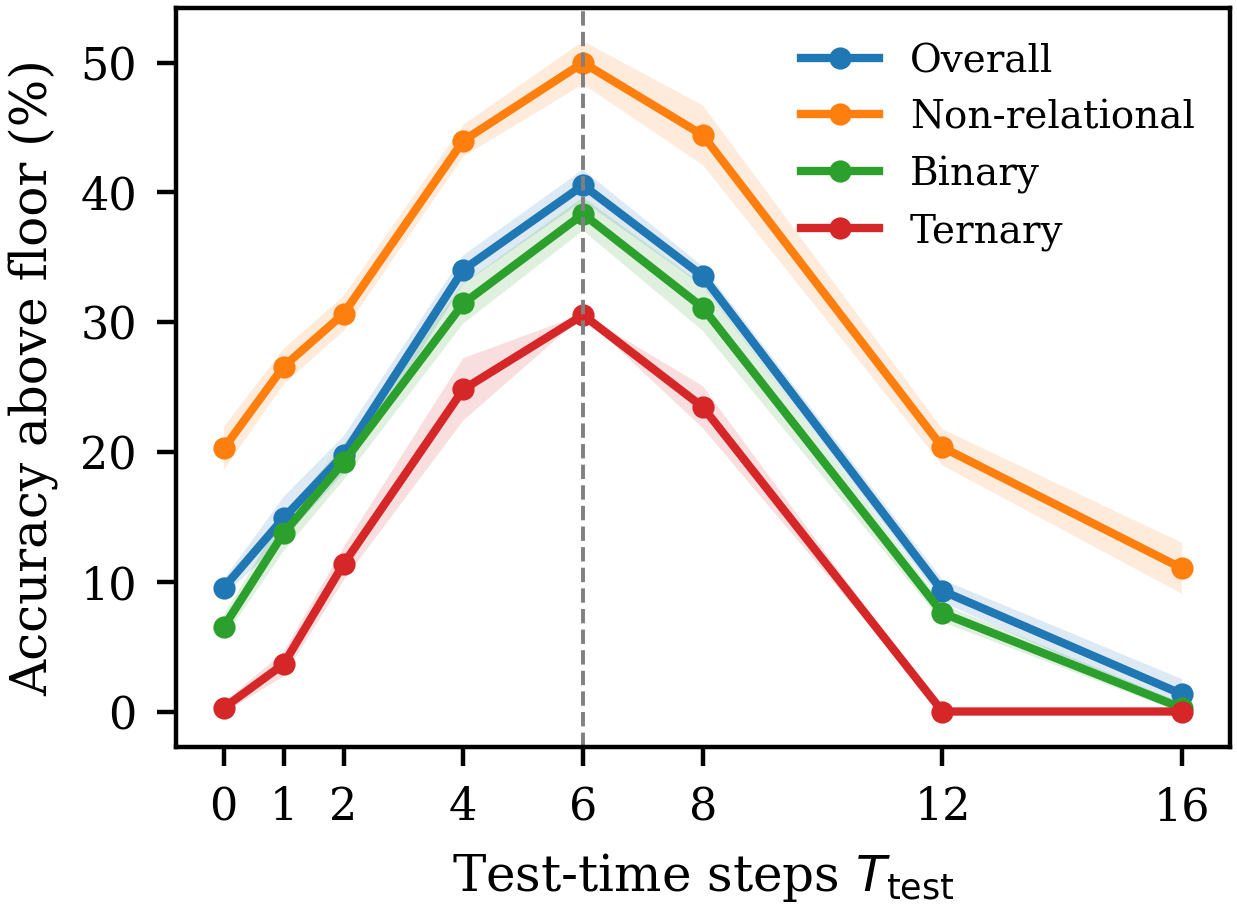

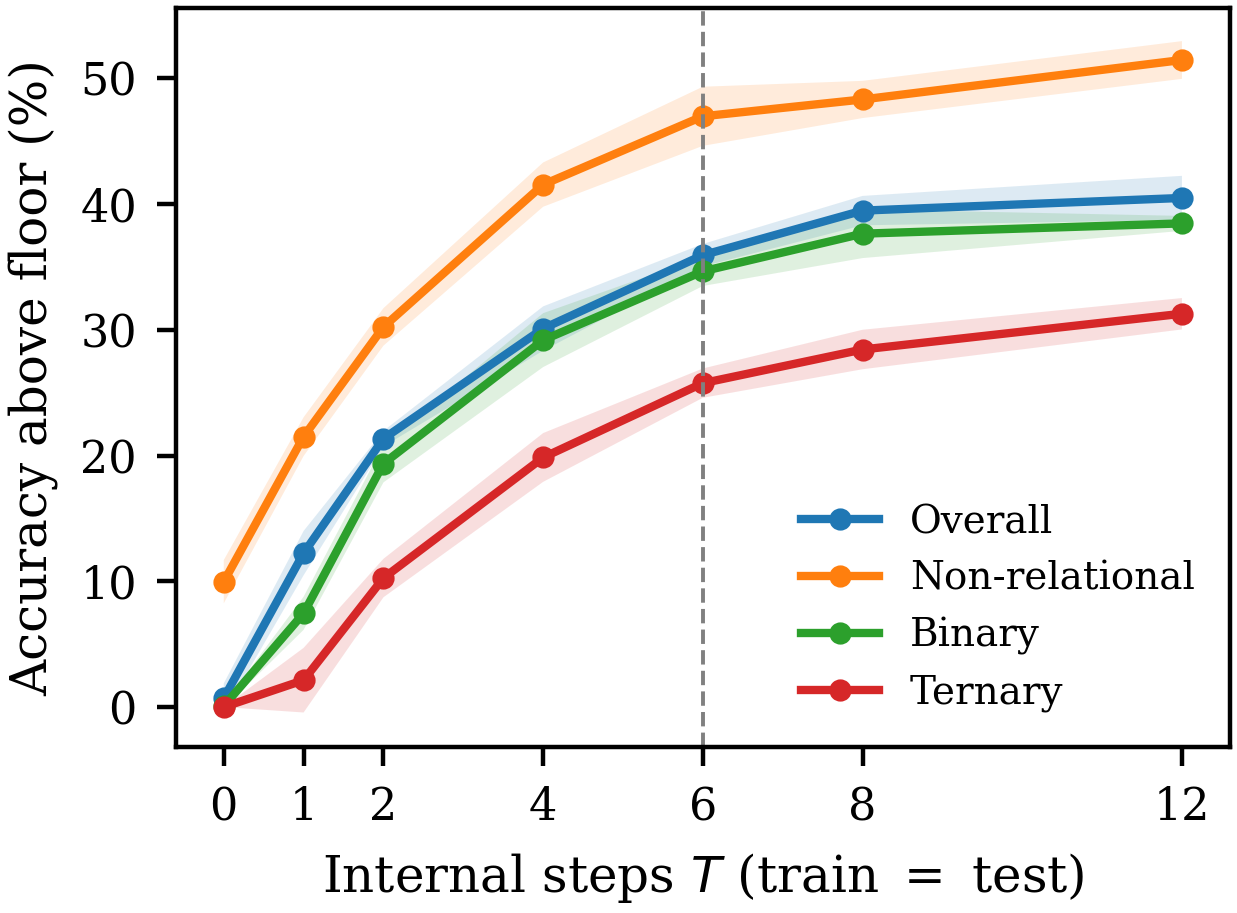

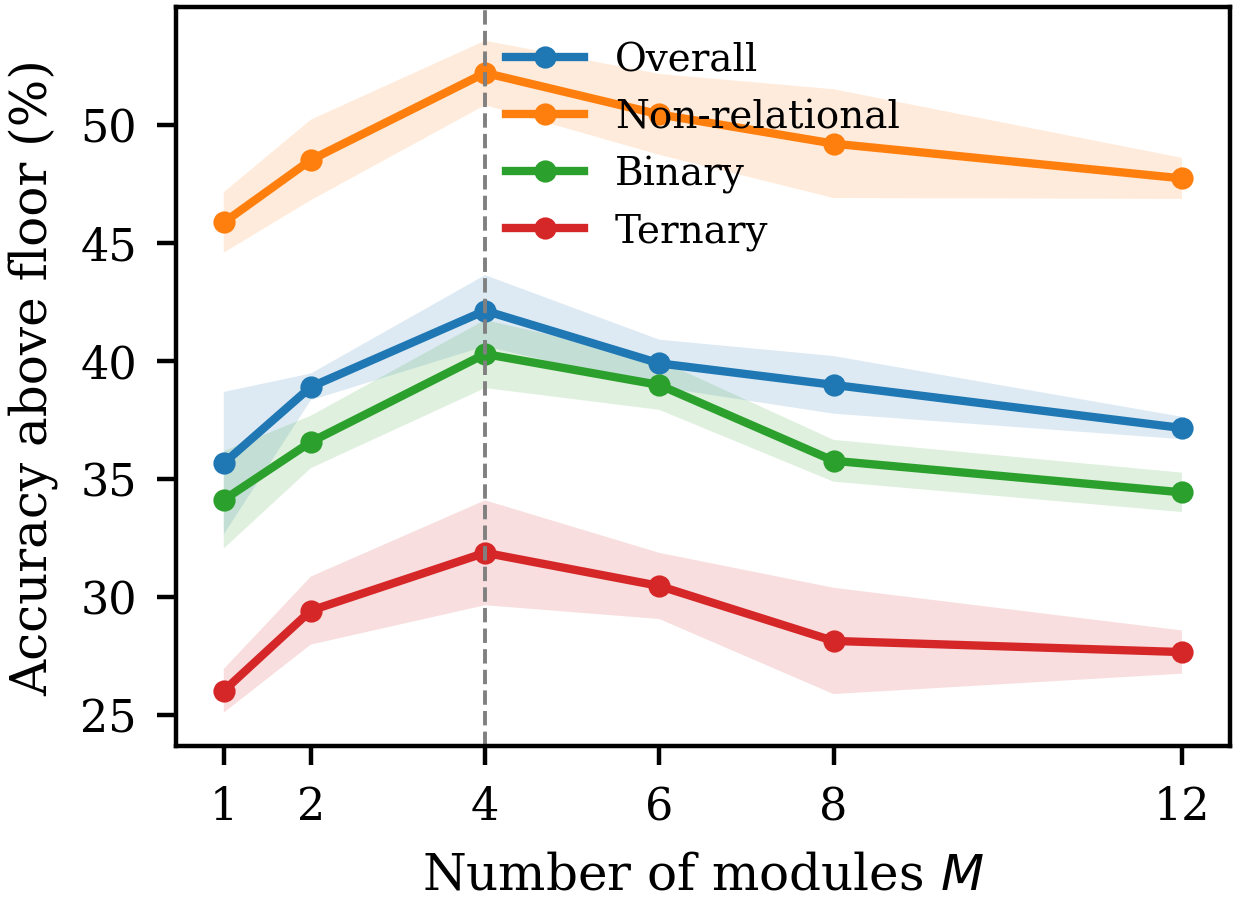

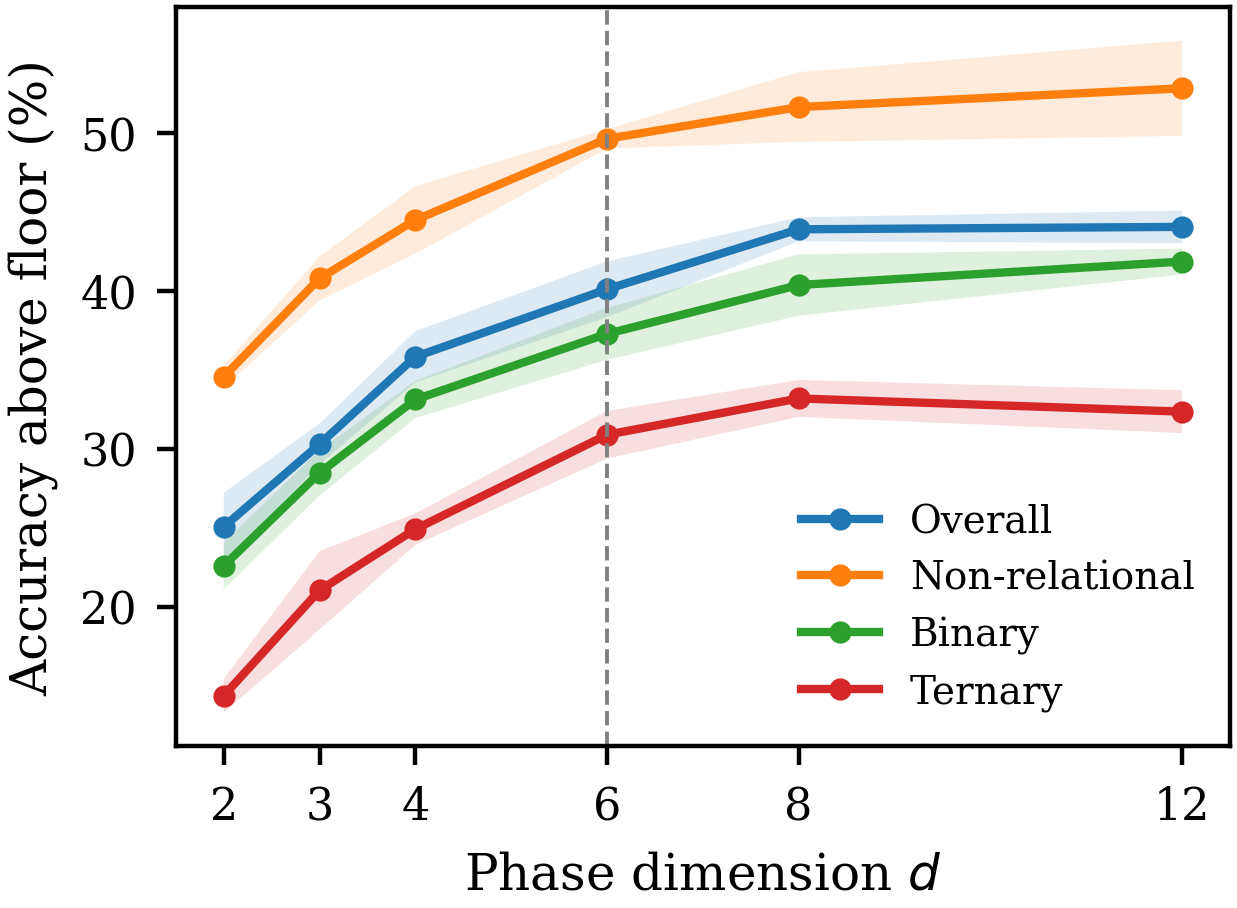

In [5]:
def ablation(res, xs, xlabel, canon, name):
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    for fam, d in res.items():
        m = np.array([d[x].mean() for x in xs])
        s = np.array([d[x].std(ddof=1) for x in xs])
        ax.plot(xs, m, marker='o', markersize=3, label=fam)
        ax.fill_between(xs, m - s, m + s, alpha=0.15)
    ax.axvline(canon, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xticks(xs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy above floor (%)')
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, name)


ablation(RES['t_test'], T_TEST, r'Test-time steps $T_{\mathrm{test}}$', T_CANON, 'soc_ablation_t_test')
ablation(RES['t_train'], T_TRAIN, r'Internal steps $T$ (train $=$ test)', T_CANON, 'soc_ablation_t_train')
ablation(RES['n_modules'], M_VALUES, r'Number of modules $M$', M_CANON, 'soc_ablation_n_modules')
ablation(RES['phase_dim'], D_VALUES, r'Phase dimension $d$', D_CANON, 'soc_ablation_phase_dim')

### results — joint train/test T (3D surface + heatmap)

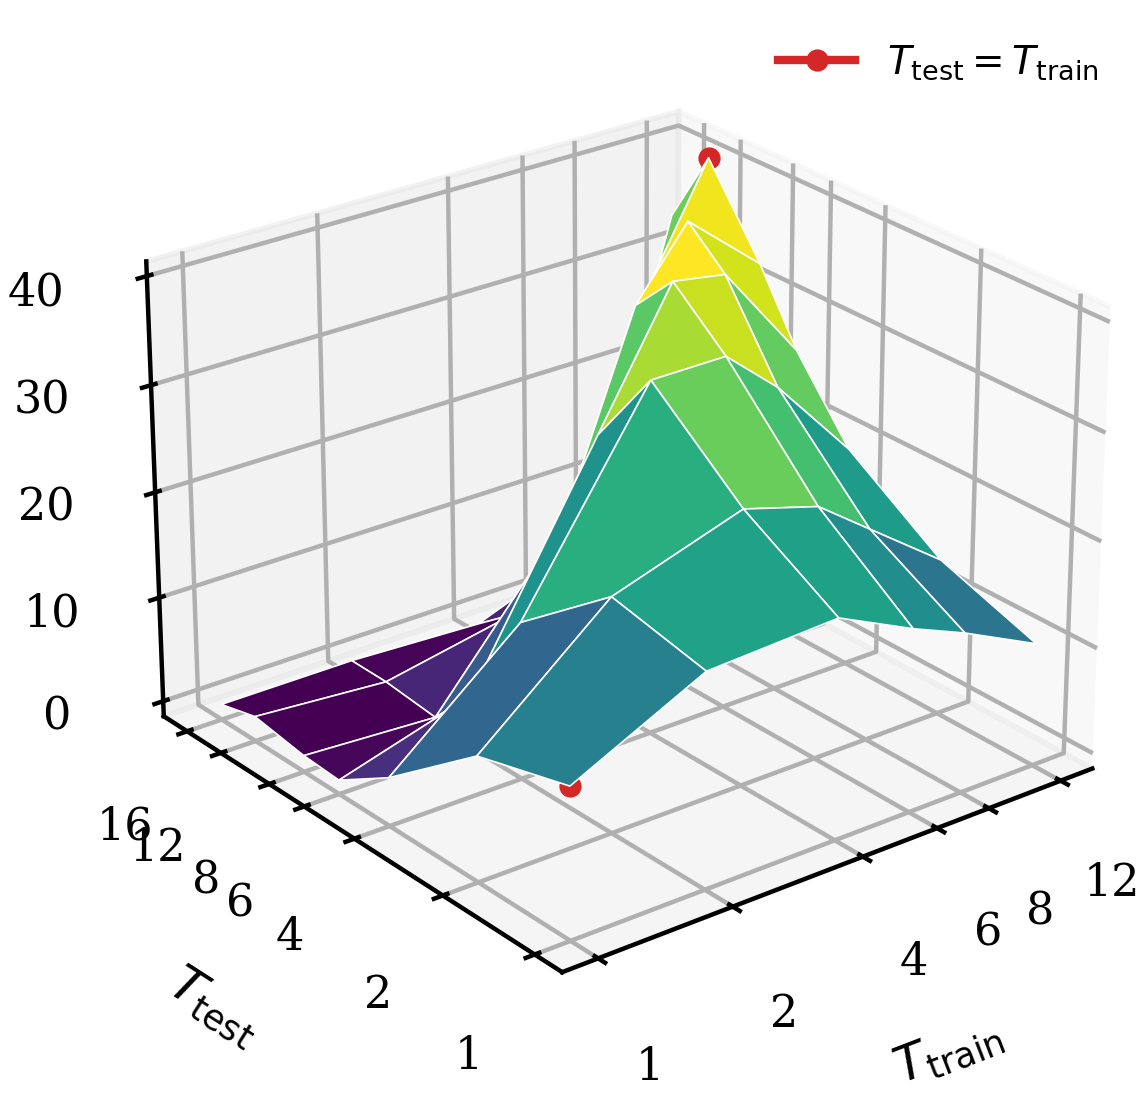

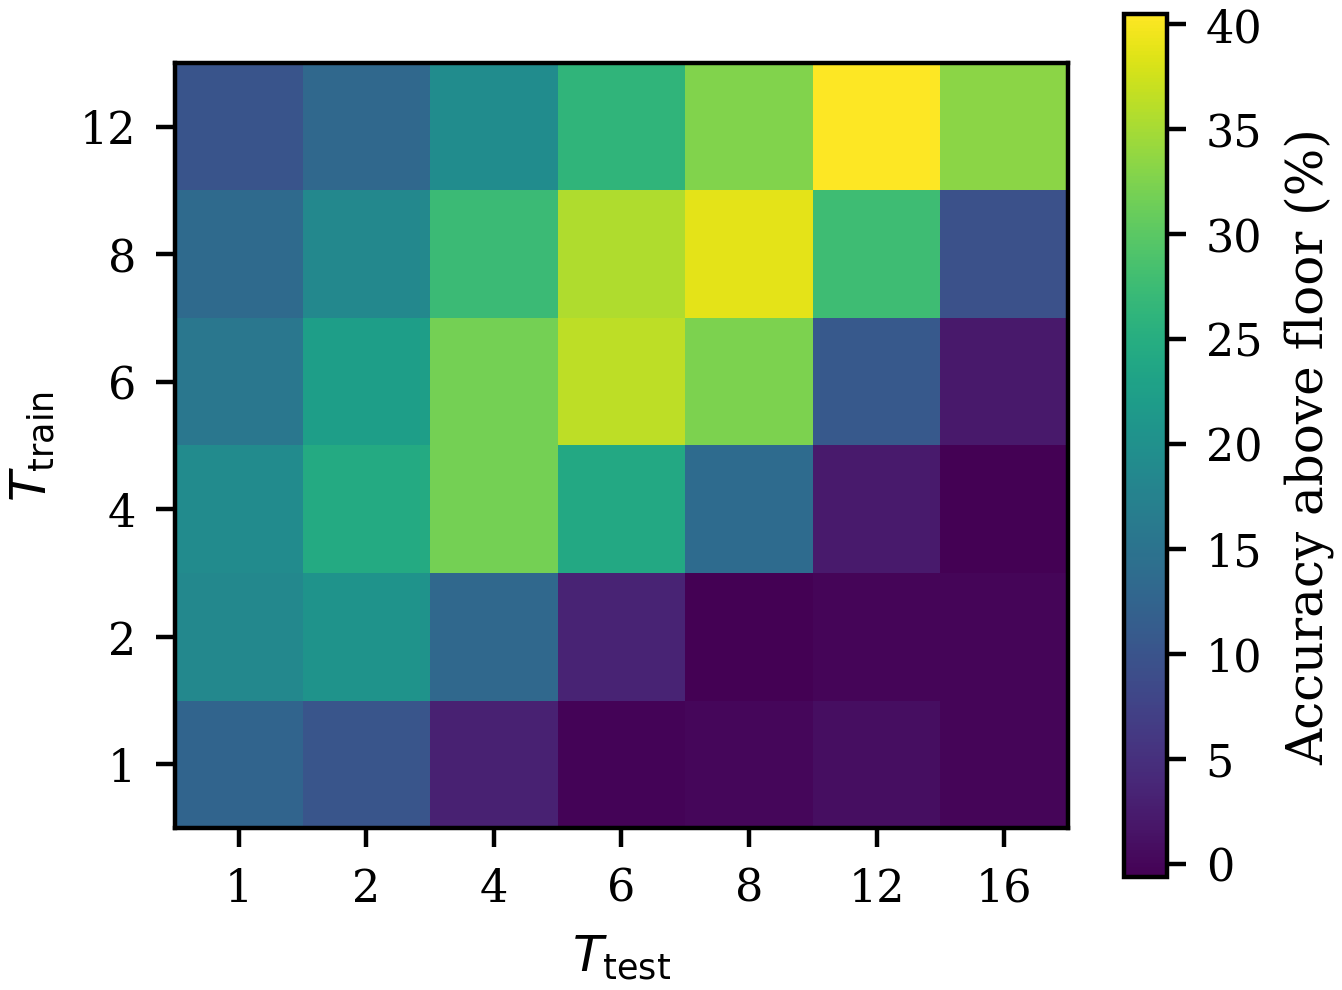

In [6]:
tr, te = T_TRAIN[1:], T_TEST[1:]
Z = T_GRID.mean(-1)
TR, TE = np.meshgrid(np.log2(tr), np.log2(te), indexing='ij')

fig = plt.figure(figsize=(4.5, 3.4))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(TR, TE, Z, cmap='viridis', edgecolor='white', linewidth=0.3)
diag = [Z[i, te.index(t)] for i, t in enumerate(tr)]
ax.plot(np.log2(tr), np.log2(tr), diag, color='C3', marker='o', markersize=3, label=r'$T_{\mathrm{test}}=T_{\mathrm{train}}$')
ax.set_xticks(np.log2(tr), tr); ax.set_yticks(np.log2(te), te)
ax.set_xlabel(r'$T_{\mathrm{train}}$'); ax.set_ylabel(r'$T_{\mathrm{test}}$'); ax.set_zlabel('Accuracy above floor (%)')
ax.view_init(elev=25, azim=-128)
ax.legend(frameon=False, fontsize=7)
save_show(fig, 'soc_ablation_t_surface')

fig, ax = plt.subplots(figsize=(3.6, 2.8))
im = ax.imshow(Z, cmap='viridis', origin='lower')
ax.set_xticks(range(len(te)), te); ax.set_yticks(range(len(tr)), tr)
ax.set_xlabel(r'$T_{\mathrm{test}}$'); ax.set_ylabel(r'$T_{\mathrm{train}}$')
fig.colorbar(im, label='Accuracy above floor (%)')
save_show(fig, 'soc_ablation_t_heatmap')

### results — SQOOP (Table 5.3)

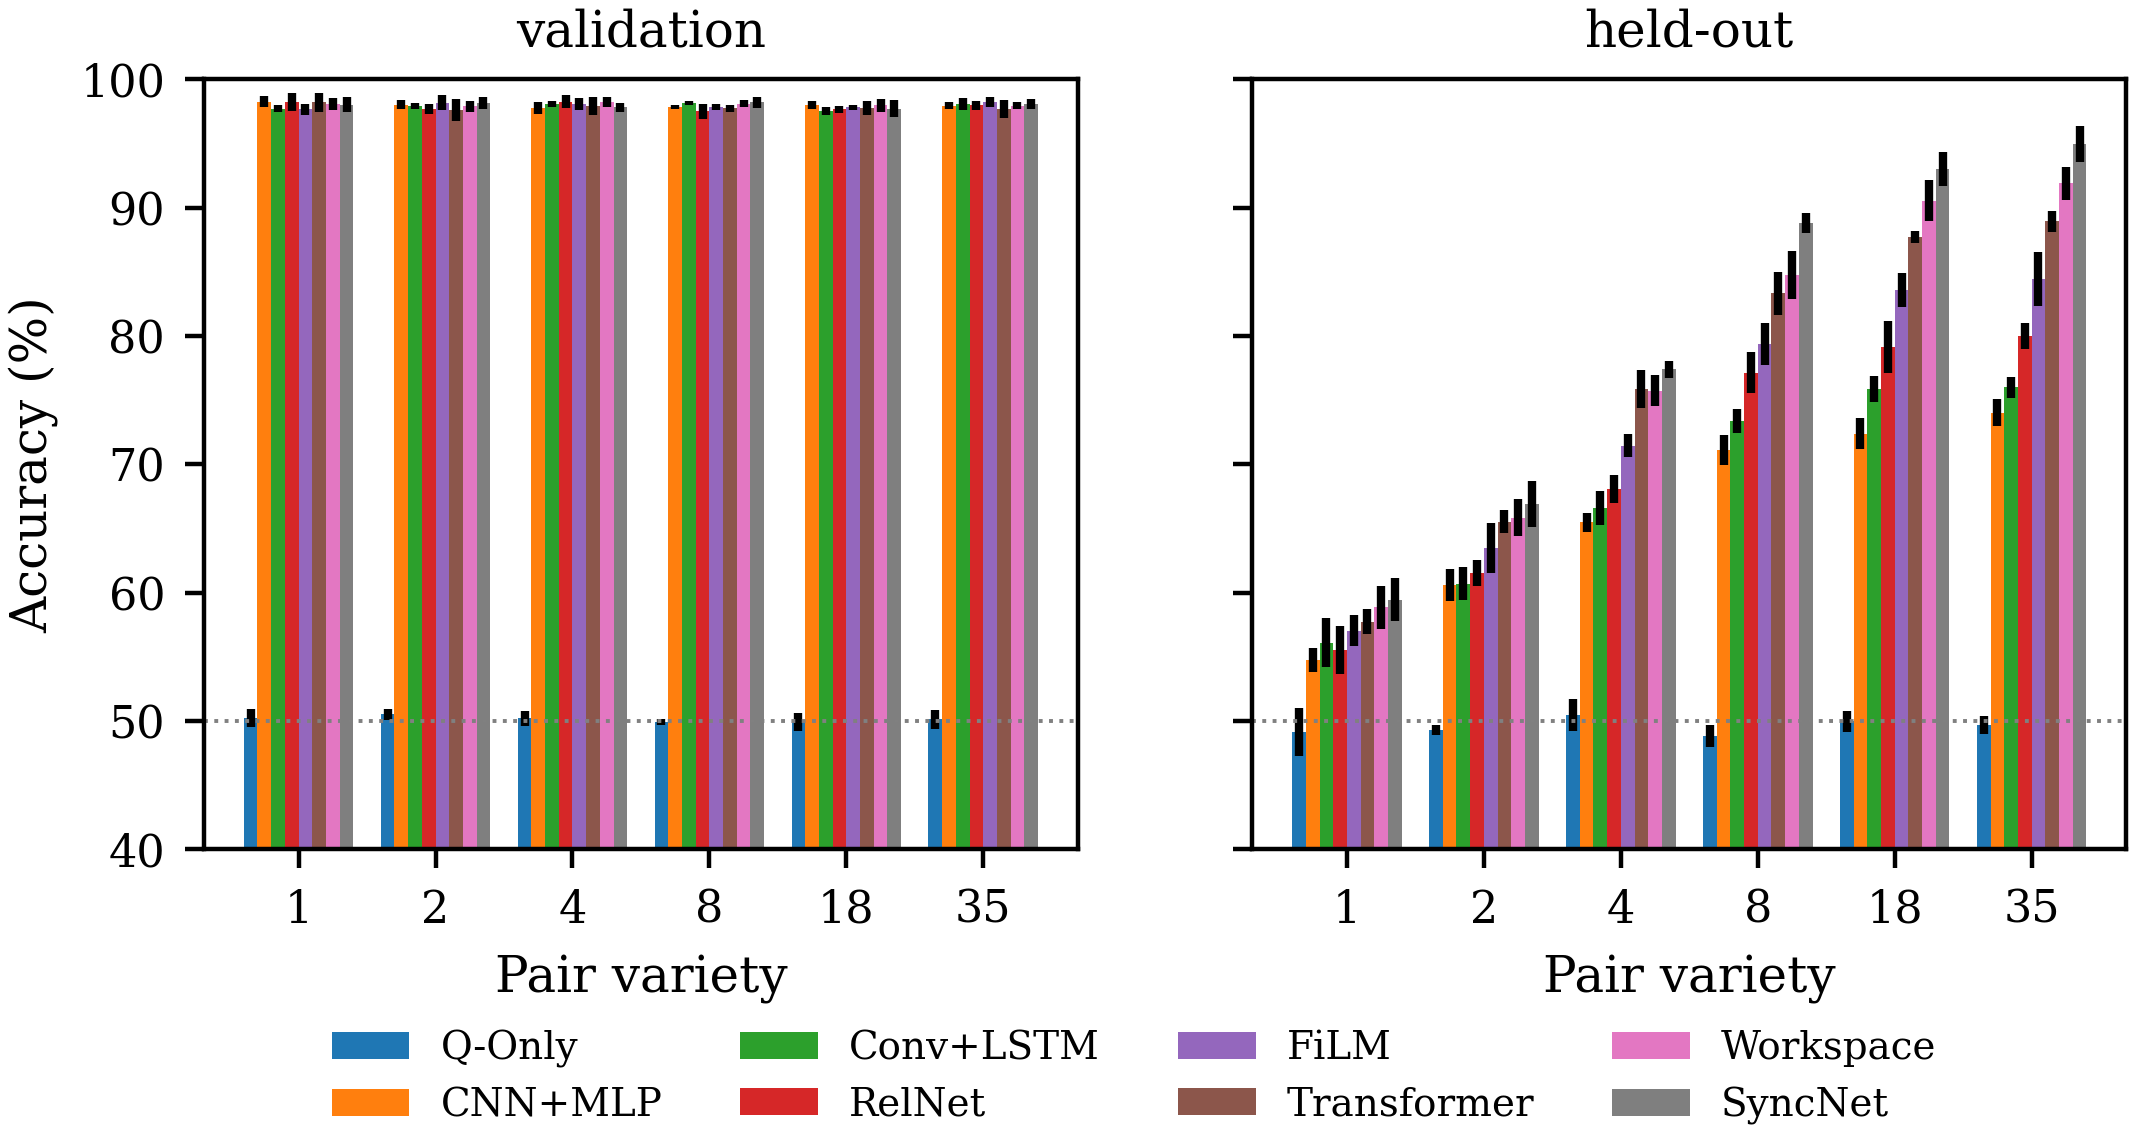

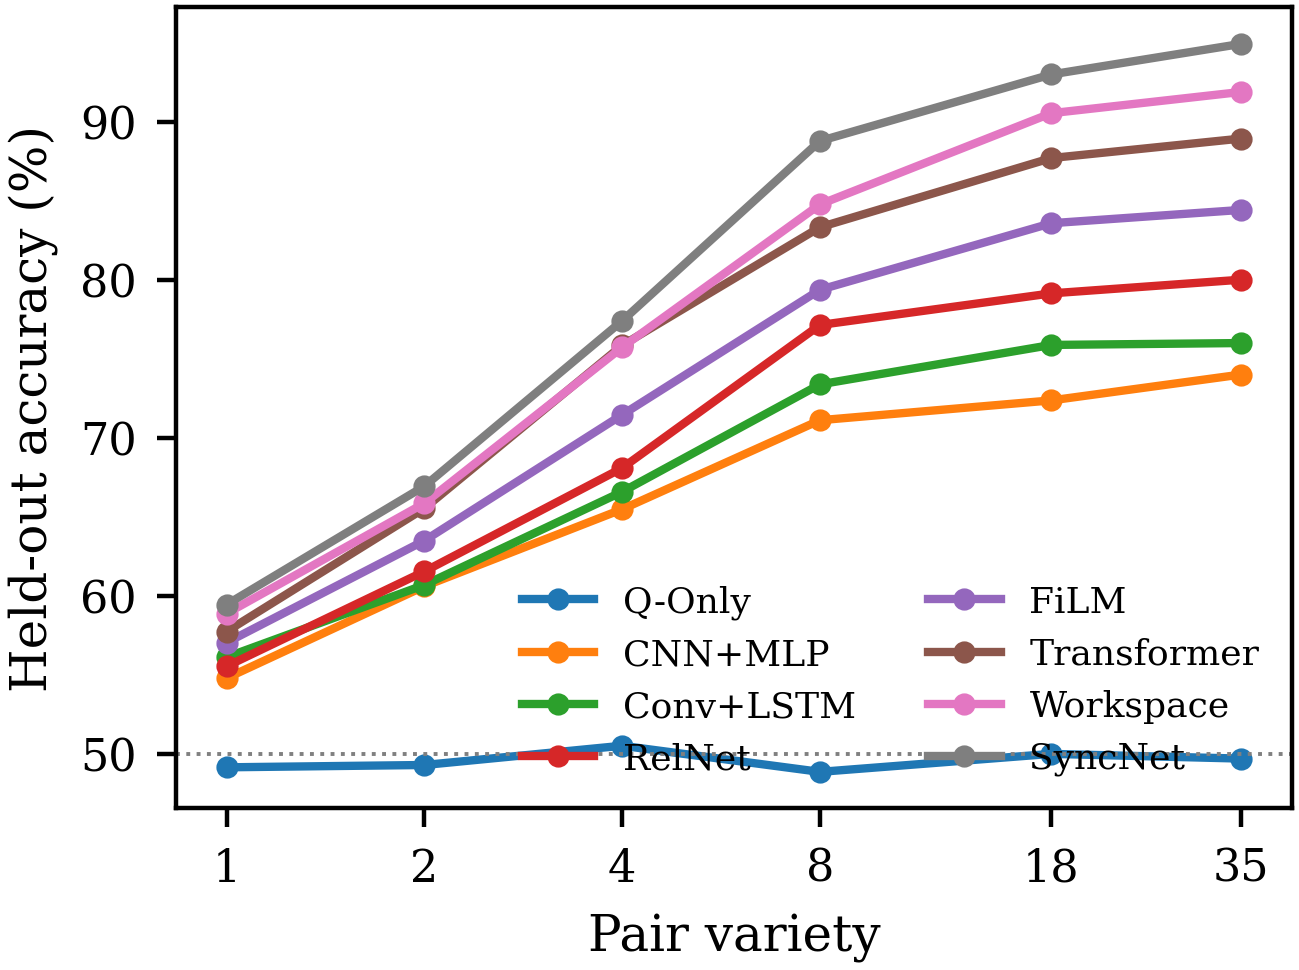

In [7]:
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        m = [100 * SQOOP[name][split][v].mean() for v in PAIR_VARIETY]
        s = [100 * SQOOP[name][split][v].std(ddof=1) for v in PAIR_VARIETY]
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_xticks(x, PAIR_VARIETY)
    ax.set_xlabel('Pair variety')
    ax.set_title(split)
    ax.set_ylim(40, 100)
axes[0].set_ylabel('Accuracy (%)')
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=7, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.2))
save_show(fig, 'sqoop_results_bars')

# alternative: held-out accuracy vs pair variety, one line per model
fig, ax = plt.subplots(figsize=(3.6, 2.6))
for name in SQOOP_MODELS:
    m = [100 * SQOOP[name]['held-out'][v].mean() for v in PAIR_VARIETY]
    ax.plot(PAIR_VARIETY, m, marker='o', markersize=3, label=name)
ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax.set_xscale('log'); ax.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax.minorticks_off()
ax.set_xlabel('Pair variety'); ax.set_ylabel('Held-out accuracy (%)')
ax.legend(frameon=False, fontsize=6.5, ncol=2, loc='lower right')
save_show(fig, 'sqoop_results_lines')